<a href="https://colab.research.google.com/github/harishmanarayanasamy123-maker/buoy_dashboard/blob/main/solar_power.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing libraries


In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

load the dataset

In [9]:
df = pd.read_csv("/content/solar_power_output.csv")
df.head()
df.tail()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
495,18.833806,27.326566,701.391519,6.569552,352.480220
496,24.591403,93.385086,657.541311,9.566146,326.834297
497,11.943366,30.945490,517.144639,0.689580,259.133251
498,34.359870,96.018988,441.807202,0.570547,223.778239
499,34.655269,55.680462,877.000285,2.821871,435.410369


In [10]:
df.isnull().sum()# data preprocessing

,0
temperature,0
humidity,0
solar_irradiance,0
wind_speed,0
solar_power_output,0


select features and target variable

In [11]:
# features and target variable
x = df[['temperature','humidity','solar_irradiance','wind_speed']]#input data
y = df['solar_power_output']#output data


split the dataset into training and testing sets(80% train ,20% test)

In [12]:
x_train, x_test, y_train ,y_test = train_test_split(x, y, train_size=0.8, random_state=42)
y_train

,solar_power_output
249,327.099129
433,352.011364
19,60.984718
322,450.400671
332,153.310006
...,...
106,223.612043
270,364.117338
348,498.628677
435,68.342178


initialize and train the linear regression model

In [13]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

predicting the solar power output on the test set

In [14]:
#predicting the solar power output on the test set
y_pred = model.predict(x_test)
y_pred

array([145.57713107,  58.80813607, 162.02529472, 389.82145928,
       499.91950594, 201.0282157 , 280.32773311, 343.94995963,
       207.65845171, 274.08855807, 270.4758993 ,  71.45181397,
       429.2717113 , 474.93452177, 131.00879232, 488.72382531,
       351.97648481,  66.01156114, 286.53039285, 315.26996554,
       156.25649583, 217.68415494, 328.50926609, 456.09724416,
       224.5996492 , 343.33441394, 258.65661936, 253.27035924,
       487.33886964, 488.13938702, 352.87341423, 139.35221981,
       486.2457442 , 166.59050109, 443.99714231, 498.93693591,
       440.23818941, 184.21480104, 497.81182991, 239.22808162,
       345.26650268, 281.34107991, 215.84679473, 472.53738059,
       105.19383876, 353.92961078, 132.62179771, 496.30985098,
       472.03357268, 464.32390435,  68.39576647, 337.05784428,
       271.45779664, 142.00782194, 330.57420011, 209.16463829,
       431.33413852, 460.5254782 , 271.68335513, 148.17216826,
       322.32496321, 189.54364635, 148.80585848,  54.32

evaluate the model performance

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

# evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared error: {r2}")

Mean Squared Error: 29.462345968246385
R-squared error: 0.9983255901416407


visualization

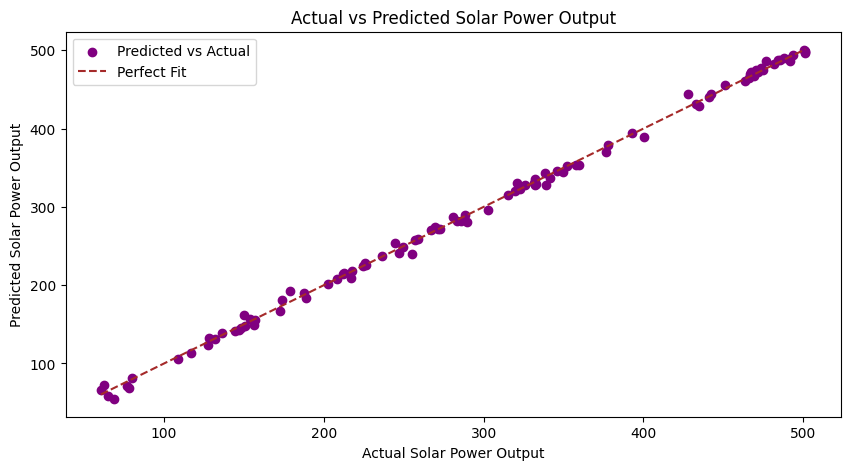

In [16]:
import matplotlib.pyplot as plt

# Scatter plot to compare actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='purple', label='Predicted vs Actual')
# Diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='brown', linestyle='--', label='Perfect Fit')
plt.xlabel("Actual Solar Power Output")
plt.ylabel("Predicted Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output")
plt.legend()
plt.show()

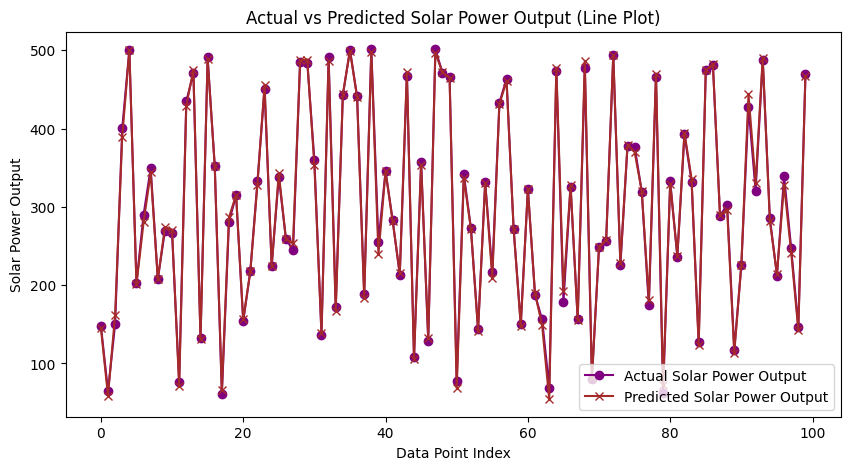

In [17]:
# Line plot to show predictions and actual values
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test,color='purple', label="Actual Solar Power Output", marker='o')
plt.plot(range(len(y_test)), y_pred, color='brown',label="Predicted Solar Power Output", marker='x')
plt.xlabel("Data Point Index")
plt.ylabel("Solar Power Output")
plt.title("Actual vs Predicted Solar Power Output (Line Plot)")
plt.legend()
plt.show()

Save the model for later use

In [18]:
# Save the trained model
import joblib
joblib.dump(model, 'solar_power_prediction_model.pkl')

['solar_power_prediction_model.pkl']

Load and use the Model

In [19]:
 #Load the saved model
model = joblib. load("solar_power_prediction_model.pkl")

# New input data for prediction
# Example input (temperature, humidity, solar_irradiance,wind_speed)
new_data = np.array([[19.36, 75.85,266.61,5.19]])

# Predict solar power output
predicted_output = model.predict(new_data)
print(f"Predicted Solar Power Output: {predicted_output[0]} watts")

Predicted Solar Power Output: 132.6167057318903 watts


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
